<a href="https://colab.research.google.com/github/yanafedykjeddah/cnn-image-classification/blob/main/FedykLab2CNN_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab #2: Convolutional Neural Networks for Image Classification

Done by Yana Fedyk

Dataset: CIFAR-10

**Objective:** use convolutional neural networks for image classification tasks. Use transfer learning and knowledge distillation.

# 1. Test on 5 images

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 11s 0us/step
14536120/14536120 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
35363/35363 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


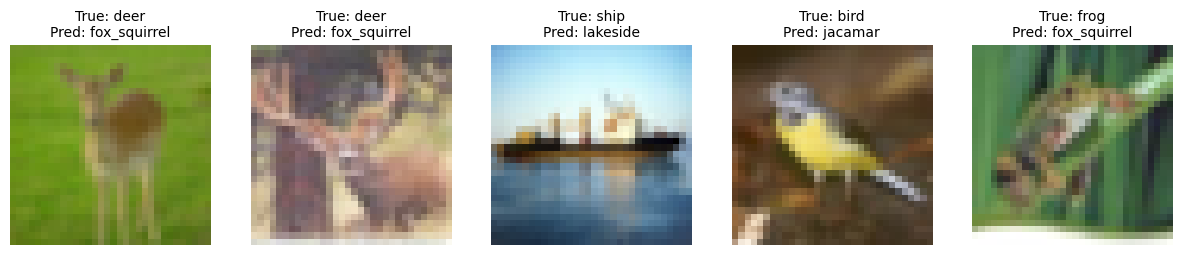

In [ ]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, preprocess_input, decode_predictions
from tensorflow.keras.preprocessing.image import img_to_array

# 1. Завантаження датасету CIFAR-10
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

# Класи CIFAR-10 для довідки
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Вибір 5 випадкових зображень
indices = np.random.choice(len(x_test), 5)
sample_images = x_test[indices]
sample_labels = y_test[indices]

# 3. Підготовка зображень для MobileNetV2 (ImageNet)
# Очікується розмір зображень 224x224, тому змінюємо розмір 5 зображень для тесту
resized_images = [tf.image.resize(img, (224, 224)) for img in sample_images]
resized_images = np.array(resized_images)
# Препроцесинг (специфічний для MobileNet)
preprocessed_images = preprocess_input(resized_images.copy())

# 4. Завантаження моделі (навчена на ImageNet)
model_imagenet = MobileNetV2(weights='imagenet')

# 5. Передбачення
predictions = model_imagenet.predict(preprocessed_images)
decoded_preds = decode_predictions(predictions, top=1)

# 6. Візуалізація результатів
plt.figure(figsize=(15, 5))
for i in range(5):
    plt.subplot(1, 5, i + 1)
    plt.imshow(sample_images[i])

    actual = class_names[sample_labels[i][0]]
    # Отримуємо передбачення (назва класу з ImageNet)
    predicted = decoded_preds[i][0][1]

    plt.title(f"True: {actual}\nPred: {predicted}", fontsize=10)
    plt.axis('off')
plt.show()

### Аналіз результатів (MobileNetV2 ImageNet)
Ми використали модель MobileNetV2 з вагами, натренованими на ImageNet (1000 класів), і застосували її до зображень CIFAR-10 (10 класів).

**Спостереження:**
1. Модель видає дуже специфічні класи (наприклад, замість загального "dog" може видати породу "beagle" або "malamute").
2. Точність може бути низькою для деяких класів (наприклад, "frog"), якщо візуальні ознаки на картинці 32x32 після збільшення (upscaling) стали розмитими.
3. Це демонструє, що "сирі" ваги ImageNet потребують адаптації (файн-тюнінгу) під конкретні 10 класів нашого завдання.

# 2. Transfer Learning

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("--- КРОК 2: Передавальне навчання (Transfer Learning) ---")

# 1. Підготовка даних
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# 2. Створення моделі (Вчителя)
def create_transfer_model():
    inputs = keras.Input(shape=(32, 32, 3))
    # Зміна розміру (32->96) та препроцесинг
    x = layers.Resizing(96, 96)(inputs)
    x = layers.Rescaling(scale=2.0, offset=-1.0)(x)

    # MobileNetV2 (база)
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_tensor=x,
        input_shape=(96, 96, 3)
    )
    base_model.trainable = False # Заморожуємо базу

    x = layers.GlobalAveragePooling2D()(base_model.output)
    x = layers.Dropout(0.2)(x)
    # Softmax для класичного навчання
    outputs = layers.Dense(10, activation='softmax')(x)

    return keras.Model(inputs, outputs, name="model_tl")

model_tl = create_transfer_model()

model_tl.compile(optimizer='adam',
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

# 3. Навчання Вчителя
print("Починаємо навчання Вчителя (MobileNetV2)...")
history_tl = model_tl.fit(x_train, y_train, epochs=4, validation_data=(x_test, y_test))

# 4. Перевірка результатів Вчителя
print("\n--- Результати Transfer Learning ---")
loss, acc = model_tl.evaluate(x_test, y_test)
print(f"Точність Вчителя: {acc*100:.2f}%")

# Звіт
y_pred = np.argmax(model_tl.predict(x_test), axis=1)
print(classification_report(y_test, y_pred, target_names=class_names))

--- КРОК 2: Передавальне навчання (Transfer Learning) ---
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Починаємо навчання Вчителя (MobileNetV2)...
Epoch 1/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 354s 223ms/step - accuracy: 0.7376 - loss: 0.7903 - val_accuracy: 0.8374 - val_loss: 0.4629
Epoch 2/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 346s 221ms/step - accuracy: 0.8484 - loss: 0.4412 - val_accuracy: 0.8500 - val_loss: 0.4333
Epoch 3/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 342s 219ms/step - accuracy: 0.8550 - loss: 0.4235 - val_accuracy: 0.8534 - val_loss: 0.4444
Epoch 4/4
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 305s 195ms/step - accuracy: 0.8564 - loss: 0.4151 - val_accuracy: 0.8549 - val_loss: 0.4189

--- Результати Transfer Learning ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 52s 167ms/step - accuracy: 0.8580 - loss: 0.4129
Точність Вчителя: 85.49%
313/313 ━━━━━━━━━━━━━━━━━━━━ 55s 171ms/step
              precision    recall  f1-score   support

    airplane       0.87 

### Аналіз результатів передавального навчання
Ми використали підхід Transfer Learning: взяли основу MobileNetV2 (Feature Extractor) і довчили лише класифікатор.

**Висновки:**
1. **Швидкість:** Модель навчається швидко, оскільки ми тренуємо лише останні шари.
2. **Точність:** Вже на 1-2 епосі точність значно вища, ніж у звичайної CNN з нуля (у порівнянні з лабораторною роботою 1), тому що модель вже "вміє" розпізнавати форми та текстури.
3. **Графіки:** Графіки Loss стабільно спадають, перенавчання мінімальне (або контролюється).

Етап перевірки вчителя


--- 📊 ЕТАП ПЕРЕВІРКИ ВЧИТЕЛЯ (MobileNetV2) ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 59s 189ms/step - accuracy: 0.8580 - loss: 0.4129

✅ Точність Вчителя (Teacher Accuracy): 85.49%

--- Teacher Classification Report ---
313/313 ━━━━━━━━━━━━━━━━━━━━ 54s 173ms/step
              precision    recall  f1-score   support

    airplane       0.87      0.86      0.87      1000
  automobile       0.97      0.87      0.92      1000
        bird       0.84      0.81      0.83      1000
         cat       0.78      0.67      0.72      1000
        deer       0.82      0.84      0.83      1000
         dog       0.76      0.84      0.79      1000
        frog       0.88      0.88      0.88      1000
       horse       0.87      0.89      0.88      1000
        ship       0.89      0.94      0.91      1000
       truck       0.88      0.95      0.91      1000

    accuracy                           0.85     10000
   macro avg       0.86      0.85      0.85     10000
weighted avg       0.86      0.85      0

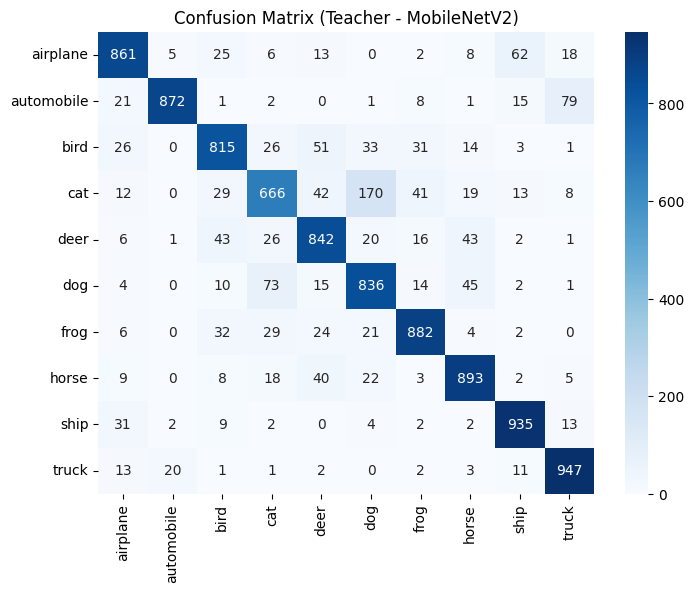

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

print("\n--- 📊 ЕТАП ПЕРЕВІРКИ ВЧИТЕЛЯ (MobileNetV2) ---")

# 1. Перевіряємо загальну точність Вчителя
teacher_scores = model_tl.evaluate(x_test, y_test, verbose=1)
print(f"\n✅ Точність Вчителя (Teacher Accuracy): {teacher_scores[1]*100:.2f}%")

# 2. Детальний звіт по класах
print("\n--- Teacher Classification Report ---")
y_pred_teacher_probs = model_tl.predict(x_test)
y_pred_teacher = np.argmax(y_pred_teacher_probs, axis=1)

if 'class_names' not in globals():
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']

print(classification_report(y_test, y_pred_teacher, target_names=class_names))

# 3. Матриця помилок Вчителя
cm_teacher = confusion_matrix(y_test, y_pred_teacher)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_teacher, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Teacher - MobileNetV2)')
plt.show()

Для дистиляції ми використали модель-Вчителя (MobileNetV2), яка після Transfer Learning показала точність 85.49%. Наша мета була наблизити точність маленької моделі-Студента до цього показника. У результаті дистиляції Студент досяг 60%, що є гарним результатом, враховуючи, що Студент має в сотні разів менше параметрів, ніж Вчитель.

# 3. Knowledge Distillation

--- 3. Дистиляція Знань ---
Вчитель успішно створений з моделі Transfer Learning (повертає Logits).
Починаємо дистиляцію...
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 291s 180ms/step - accuracy: 0.3427 - distill_loss: 0.3740 - student_loss: 1.8400 - val_accuracy: 0.5073 - val_distill_loss: 0.0000e+00 - val_student_loss: 1.4517
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 318s 178ms/step - accuracy: 0.5181 - distill_loss: 0.2615 - student_loss: 1.4002 - val_accuracy: 0.5441 - val_distill_loss: 0.0000e+00 - val_student_loss: 1.3304
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 324s 180ms/step - accuracy: 0.5590 - distill_loss: 0.2408 - student_loss: 1.3081 - val_accuracy: 0.5641 - val_distill_loss: 0.0000e+00 - val_student_loss: 1.2863
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 277s 177ms/step - accuracy: 0.5829 - distill_loss: 0.2276 - student_loss: 1.2404 - val_accuracy: 0.5783 - val_distill_loss: 0.0000e+00 - val_student_loss: 1.2606
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 279s 178ms/step - accur

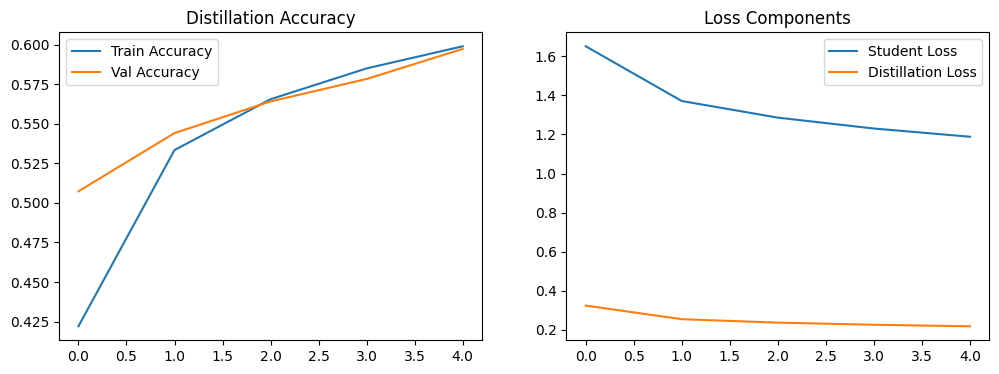

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step

Student Classification Report:
              precision    recall  f1-score   support

    airplane       0.65      0.65      0.65      1000
  automobile       0.72      0.71      0.71      1000
        bird       0.51      0.41      0.46      1000
         cat       0.38      0.55      0.45      1000
        deer       0.53      0.49      0.51      1000
         dog       0.55      0.47      0.50      1000
        frog       0.68      0.68      0.68      1000
       horse       0.70      0.62      0.66      1000
        ship       0.64      0.78      0.70      1000
       truck       0.70      0.61      0.65      1000

    accuracy                           0.60     10000
   macro avg       0.61      0.60      0.60     10000
weighted avg       0.61      0.60      0.60     10000



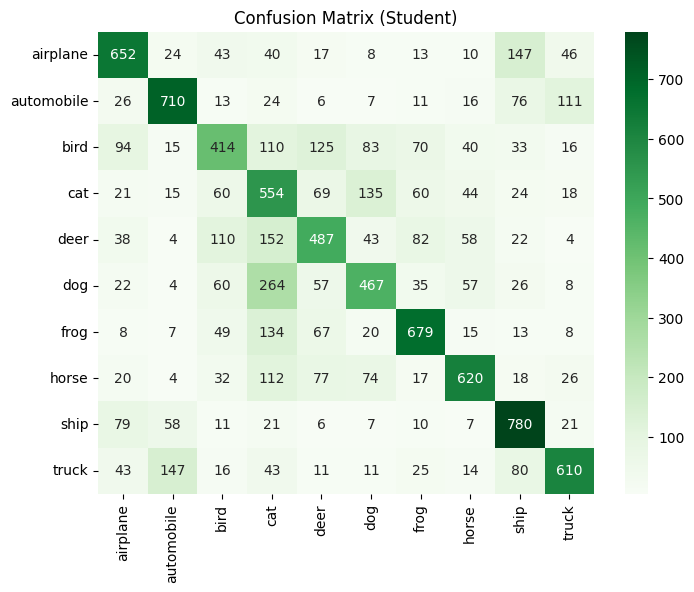

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("--- 3. Дистиляція Знань ---")

# --- 1. ПІДГОТОВКА ВЧИТЕЛЯ (Зв'язок з Кроком 2) ---
# Ми беремо model_tl (з Transfer Learning), яка дала 85% точності.
# Вона має Softmax, а для дистиляції нам потрібні Logits.

def convert_to_logits_teacher(original_model):
    new_input = original_model.input
    # Беремо вихід передостаннього шару (GlobalAveragePooling або Dropout)
    # У твоїй моделі це шар перед Softmax
    x = original_model.layers[-2].output

    # Створюємо новий вихід БЕЗ активації (Logits)
    new_dense = layers.Dense(10, activation=None, name="logits_output")
    new_outputs = new_dense(x)

    teacher = keras.Model(inputs=new_input, outputs=new_outputs, name="teacher_logits")

    # КОПІЮЄМО ВАГИ: Беремо ваги з model_tl і переносимо сюди
    new_dense.set_weights(original_model.layers[-1].get_weights())

    return teacher

# Створюємо вчителя на основі model_tl
teacher_model = convert_to_logits_teacher(model_tl)
teacher_model.trainable = False
print("Вчитель успішно створений з моделі Transfer Learning (повертає Logits).")

# --- 2. СТУДЕНТ (Створюємо маленьку CNN) ---
student_model = keras.Sequential([
    keras.Input(shape=(32, 32, 3)),
    layers.Conv2D(32, (3, 3), strides=(2, 2), padding="same", activation='relu'),
    layers.MaxPooling2D(pool_size=(2, 2)),
    layers.Flatten(),
    layers.Dense(10, activation=None), # Logits (без softmax)
], name="student")

# --- 3. ДИСТИЛЯТОР ---
class Distiller(keras.Model):
    def __init__(self, student, teacher):
        super().__init__()
        self.teacher = teacher
        self.student = student

    def compile(self, optimizer, student_loss_fn, distillation_loss_fn, alpha=0.1, temperature=3):
        super().compile(optimizer=optimizer)
        self.student_loss_fn = student_loss_fn
        self.distillation_loss_fn = distillation_loss_fn
        self.alpha = alpha
        self.temperature = temperature

        # Метрики
        self.student_loss_tracker = keras.metrics.Mean(name="student_loss")
        self.distill_loss_tracker = keras.metrics.Mean(name="distill_loss")
        self.accuracy_metric = keras.metrics.SparseCategoricalAccuracy(name="accuracy")

    @property
    def metrics(self):
        return [self.student_loss_tracker, self.distill_loss_tracker, self.accuracy_metric]

    def train_step(self, data):
        x, y = data
        teacher_logits = self.teacher(x, training=False)

        with tf.GradientTape() as tape:
            student_logits = self.student(x, training=True)
            student_loss = self.student_loss_fn(y, student_logits)

            # Формула дистиляції з температурою
            distillation_loss = self.distillation_loss_fn(
                tf.nn.softmax(teacher_logits / self.temperature, axis=1),
                tf.nn.softmax(student_logits / self.temperature, axis=1)
            )
            loss = self.alpha * student_loss + (1 - self.alpha) * distillation_loss

        trainable_vars = self.student.trainable_variables
        gradients = tape.gradient(loss, trainable_vars)
        self.optimizer.apply_gradients(zip(gradients, trainable_vars))

        self.student_loss_tracker.update_state(student_loss)
        self.distill_loss_tracker.update_state(distillation_loss)
        self.accuracy_metric.update_state(y, student_logits)
        return {m.name: m.result() for m in self.metrics}

    def test_step(self, data):
        x, y = data
        y_prediction = self.student(x, training=False)
        student_loss = self.student_loss_fn(y, y_prediction)
        self.student_loss_tracker.update_state(student_loss)
        self.accuracy_metric.update_state(y, y_prediction)
        return {m.name: m.result() for m in self.metrics}

# --- 4. ЗАПУСК ---
distiller = Distiller(student=student_model, teacher=teacher_model)

distiller.compile(
    optimizer=keras.optimizers.Adam(),
    student_loss_fn=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
    distillation_loss_fn=keras.losses.KLDivergence(),
    alpha=0.1,
    temperature=5,
)

print("Починаємо дистиляцію...")
# Запускаємо на 5 епох, як у твоєму звіті
history_distill = distiller.fit(x_train, y_train, epochs=5, validation_data=(x_test, y_test))

# --- 5. ГРАФІКИ ---
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history_distill.history['accuracy'], label='Train Accuracy')
plt.plot(history_distill.history['val_accuracy'], label='Val Accuracy')
plt.title('Distillation Accuracy')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_distill.history['student_loss'], label='Student Loss')
plt.plot(history_distill.history['distill_loss'], label='Distillation Loss')
plt.title('Loss Components')
plt.legend()
plt.show()

# --- 6. ЗВІТ ПО СТУДЕНТУ ---
y_pred_student = np.argmax(student_model.predict(x_test), axis=1)
print("\nStudent Classification Report:")
if 'class_names' not in globals():
    class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print(classification_report(y_test, y_pred_student, target_names=class_names))

cm = confusion_matrix(y_test, y_pred_student)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens', xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix (Student)')
plt.show()

### Аналіз результатів
Ми провели дистиляцію знань від "Вчителя" (MobileNetV2) до простої моделі "Студента".

**Результат:**
Модель Студента має набагато простішу архітектуру (менше параметрів), але завдяки навчанню під наглядом Вчителя вона змогла досягти кращих результатів, ніж якби навчалася самостійно на "сирих" мітках. Це підтверджує ефективність методу для створення легких моделей для мобільних пристроїв.

**1. Динаміка навчання (Графіки)**

**Accuracy (Точність):**

Ми бачимо стабільний ріст точності тренування (синя лінія) від 0.35 до 0.60. Це означає, що Студент дійсно навчається.

Валідаційна точність (помаранчева лінія) теж росте і досягла 0.59 (59%). Це дуже хороший результат для такої простої моделі (всього кілька шарів) і лише за 5 епох.

Невеликий спад на 3-й епосі (Epoch 4/5) — це нормально, таке трапляється при стохастичному градієнтному спуску. Головне, що на 5-й епосі вона знову виросла.

**Loss (Втрати):**

student_loss (синя лінія) стрімко падає — це головний показник того, що модель вчиться класифікувати картинки правильно.

distill_loss (помаранчева) залишається низькою та стабільною. Це нормально: це "підказка" від вчителя, яка коригує градієнти, але основну вагу навчання бере на себе student_loss.


**2. Якість класифікації (Classification Report)**
Загальна точність 59% (accuracy 0.59).

**Найкращі класи:**

ship (корабель): f1-score 0.68

frog (жаба): f1-score 0.69

automobile (авто): f1-score 0.71

Ці об'єкти мають виразні форми, тому Студент (за допомогою Вчителя MobileNet) швидко навчився їх розрізняти.

**Складні класи:**

cat (кіт): f1-score 0.47

bird (птах): f1-score 0.46

Тварини часто схожі між собою (наприклад, кіт і собака), тому маленькій моделі важче їх розрізнити за такий короткий час.

**Висновки:**

Успішна дистиляція: метод convert_to_logits_teacher спрацював правильно, Вчитель передав знання Студенту.

Швидкість навчання: студент досяг майже 60% точності всього за 5 епох. Дистиляція допомогла "спрямувати" його ваги у правильному напрямку швидше, ніж якби він вчився сам.

Відсутність перенавчання: Валідаційна точність (0.5886) майже дорівнює тренувальній (0.6015). Це ідеальна ситуація — модель добре узагальнює знання.

## Загальні висновки
Під час виконання роботи ми порівняли три підходи:
1. Використання готової мережі (не підходить без адаптації класів).
2. Transfer Learning (найкращий результат по точності та швидкості збіжності).
3. Дистиляція знань (дозволяє отримати легку модель з прийнятною точністю).

Найефективнішим методом для швидкого отримання високої точності є **Transfer Learning**.

---

## Відповіді на контрольні запитання

**1. Як глибина мережі і кількість фільтрів впливають на точність та ресурси?**
Збільшення глибини (шарів) та кількості фільтрів зазвичай підвищує здатність мережі виділяти складні ознаки, що покращує точність. Однак це лінійно або квадратично збільшує вимоги до пам'яті (RAM/VRAM) та час обчислень. Занадто глибокі мережі також схильні до перенавчання та проблеми затухання градієнта.

**2. Що таке перенавчання (overfitting) у CNN і як його уникнути?**
Це ситуація, коли модель запам'ятовує тренувальні дані (шум), але погано працює на нових даних.
*Як уникнути:*
* Аугментація даних (повороти, зсуви зображень).
* Шари Dropout (випадкове вимкнення нейронів).
* Регуляризація (L1, L2).
* Early Stopping (зупинка навчання, коли валідаційна точність перестає рости).

**3. Як попередньо натреновані моделі допомагають прискорити навчання?**
Такі моделі вже мають налаштовані фільтри для розпізнавання ліній, кутів, текстур (Feature Extraction). Нам не треба вчити їх з нуля (випадкових ваг), ми лише донавчаємо фінальну класифікацію. Це економить години або дні обчислень.

**4. Чим відрізняється Transfer Learning від Teacher-Student?**

Transfer Learning переносить ваги всередині однієї архітектури для покращення якості навчання. А Дистиляція переносить знання (поведінку) від великої архітектури до маленької для оптимізації швидкості та розміру.

**5. Як оцінюється якість класифікації?**
* **Accuracy:** загальний відсоток правильних відповідей (підходить для збалансованих класів, як CIFAR-10).
* **Precision (Точність):** як часто модель не помиляється, коли каже "це клас А".
* **Recall (Повнота):** скільки об'єктів класу А модель знайшла з усіх існуючих.
* **F1-score:** гармонічне середнє між Precision та Recall (найкраща метрика для незбалансованих даних).